# 📊 Customer Churn Prediction — Telco Dataset
### MPMD2.2 | CRISP-DM Framework
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, RocCurveDisplay
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

---
## 1. BUSINESS UNDERSTANDING

**Problem:** A telecom company loses revenue every time a customer cancels their subscription (churns). Acquiring a new customer costs 5–25× more than retaining one. The company wants to proactively identify customers **at risk of churning** so the retention team can intervene before it is too late (e.g., offer a discount, upgrade, or support call).

**Business Question:** *Can we predict which customers are likely to churn in the next period, and which factors drive that decision?*

**Success Metrics (Business KPIs):**
- **Recall (Sensitivity)** for churners: we want to catch as many at-risk customers as possible — missing a churner (False Negative) is costly.
- **ROC-AUC**: measures how well the model separates churners from non-churners across all thresholds.
- **Precision**: we also care about not wasting retention budget on customers who would have stayed anyway (False Positives).

> 💡 In churn prediction, **Recall > Precision** in business priority — it is better to contact someone unnecessarily than to lose them.

---
## 2. DATA UNDERSTANDING

**Dataset:** IBM Telco Customer Churn — 7,043 customers, 33 variables.

**Key variable groups:**
| Group | Variables |
|---|---|
| Demographics | Gender, Senior Citizen, Partner, Dependents |
| Services | Phone, Internet, Online Security, Tech Support, Streaming |
| Account | Contract type, Payment Method, Billing, Monthly & Total Charges, Tenure |
| Target | Churn Label (Yes/No) |

In [2]:
# ── LOAD DATA ──────────────────────────────────────────────────────────────────
# Update this path to your local file location
path = r"Telco_customer_churn.xlsx"  # <-- update as needed
df = pd.read_excel(path)

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
df.head(3)

Shape: (7043, 33)

Columns:
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved


In [3]:
# ── BASIC DATA QUALITY CHECK ───────────────────────────────────────────────────
# WHY: Before any analysis we must understand completeness, types, and duplicates.
# This dataset has one column with many NaNs: 'Churn Reason' — only churned
# customers have a reason, so 5,174 NaNs = non-churners. This is expected.
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0])

print(f"\n=== Duplicates: {df.duplicated().sum()} ===")
print(f"\n=== Data Types ===")
print(df.dtypes)

=== Missing Values ===
Churn Reason    5174
dtype: int64

=== Duplicates: 0 ===

=== Data Types ===
CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
C

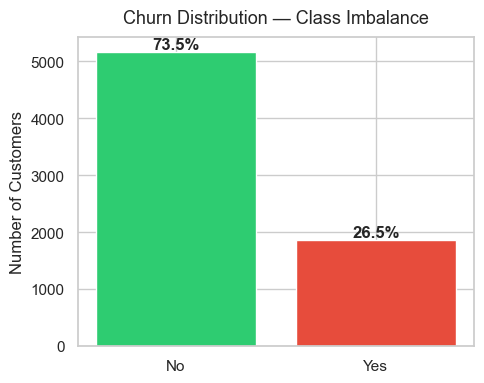


Churn rate: 26.5% — dataset is imbalanced (26.5% churners)
→ We will use class_weight='balanced' in both models to compensate.


In [4]:
# ── TARGET VARIABLE: CLASS DISTRIBUTION ───────────────────────────────────────
# WHY: Class imbalance affects model training. If we train naively, the model
# may predict 'No churn' for everyone and still get 73% accuracy — which is
# useless. We will address this with class_weight='balanced'.

churn_counts = df['Churn Label'].value_counts()
churn_pct = df['Churn Label'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(churn_counts.index, churn_counts.values,
              color=['#2ecc71', '#e74c3c'], edgecolor='white')
for bar, pct in zip(bars, churn_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{pct:.1f}%', ha='center', fontweight='bold')
ax.set_title('Churn Distribution — Class Imbalance', fontsize=13, pad=10)
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.show()

print(f"\nChurn rate: {churn_pct['Yes']:.1f}% — dataset is imbalanced (26.5% churners)")
print("→ We will use class_weight='balanced' in both models to compensate.")

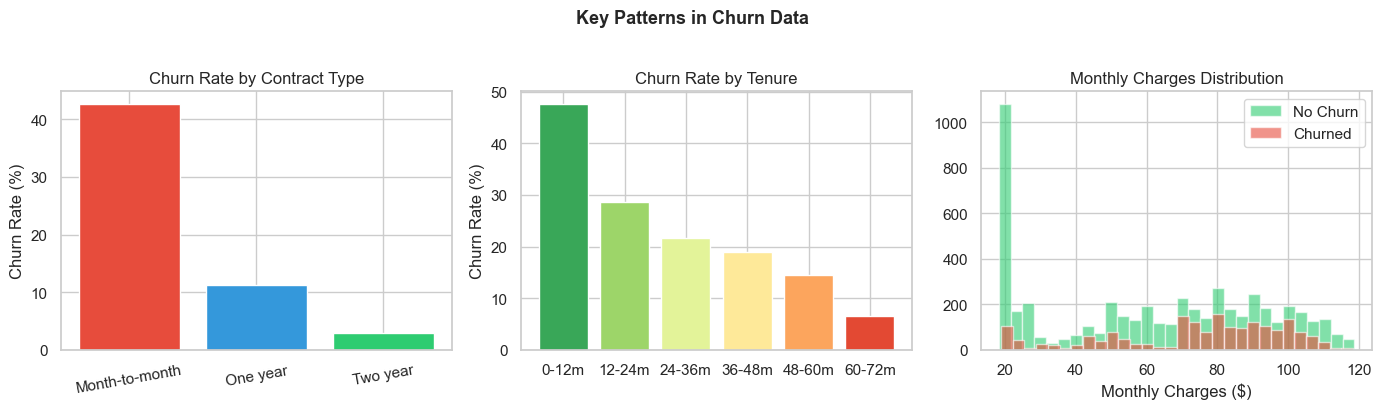

In [5]:
# ── EDA: WHO CHURNS AND WHY? ───────────────────────────────────────────────────
# WHY: Before modeling, we visualize key patterns. These charts also become
# the business story in the presentation.

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Contract Type vs Churn
# FINDING: Month-to-month customers churn far more — no long-term commitment.
contract_churn = df.groupby('Contract')['Churn Label'].apply(
    lambda x: (x == 'Yes').mean() * 100).reset_index()
contract_churn.columns = ['Contract', 'Churn Rate (%)']
axes[0].bar(contract_churn['Contract'], contract_churn['Churn Rate (%)'],
            color=['#e74c3c', '#3498db', '#2ecc71'])
axes[0].set_title('Churn Rate by Contract Type')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].tick_params(axis='x', rotation=10)

# 2. Tenure vs Churn
# FINDING: New customers (low tenure) churn far more — the first months are critical.
df['Tenure Group'] = pd.cut(df['Tenure Months'],
                             bins=[0, 12, 24, 36, 48, 60, 72],
                             labels=['0-12m', '12-24m', '24-36m', '36-48m', '48-60m', '60-72m'])
tenure_churn = df.groupby('Tenure Group', observed=True)['Churn Label'].apply(
    lambda x: (x == 'Yes').mean() * 100).reset_index()
tenure_churn.columns = ['Tenure Group', 'Churn Rate (%)']
axes[1].bar(tenure_churn['Tenure Group'], tenure_churn['Churn Rate (%)'],
            color=sns.color_palette('RdYlGn_r', len(tenure_churn)))
axes[1].set_title('Churn Rate by Tenure')
axes[1].set_ylabel('Churn Rate (%)')

# 3. Monthly Charges vs Churn
# FINDING: Churners pay higher monthly charges on average.
churners = df[df['Churn Label'] == 'Yes']['Monthly Charges']
non_churners = df[df['Churn Label'] == 'No']['Monthly Charges']
axes[2].hist(non_churners, bins=30, alpha=0.6, label='No Churn', color='#2ecc71')
axes[2].hist(churners, bins=30, alpha=0.6, label='Churned', color='#e74c3c')
axes[2].set_title('Monthly Charges Distribution')
axes[2].set_xlabel('Monthly Charges ($)')
axes[2].legend()

plt.suptitle('Key Patterns in Churn Data', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

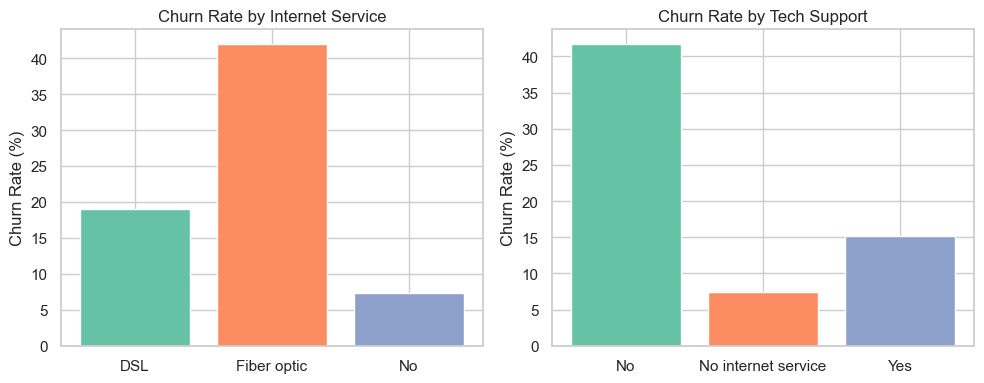

In [6]:
# ── EDA: INTERNET SERVICE & TECH SUPPORT ──────────────────────────────────────
# FINDING: Fiber Optic customers churn more. Customers WITHOUT Tech Support churn more.
# Business insight: upsell Tech Support, investigate Fiber Optic service quality.

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for col, ax, title in [
    ('Internet Service', axes[0], 'Churn Rate by Internet Service'),
    ('Tech Support', axes[1], 'Churn Rate by Tech Support')
]:
    grp = df.groupby(col)['Churn Label'].apply(
        lambda x: (x == 'Yes').mean() * 100).reset_index()
    grp.columns = [col, 'Churn Rate (%)']
    ax.bar(grp[col], grp['Churn Rate (%)'], color=sns.color_palette('Set2', len(grp)))
    ax.set_title(title)
    ax.set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

---
## 3. DATA PREPARATION

Steps:
1. **Remove data leakage** — variables that contain churn information (`Churn Score`, `Churn Value`, `Churn Reason`, `CLTV`) cannot be used as features because they would not be available in a real-time prediction scenario.
2. **Remove irrelevant identifiers** — CustomerID, location columns, etc.
3. **Fix data types** — `Total Charges` is stored as string (object), needs conversion.
4. **Encode categoricals** — one-hot encoding for all text features.
5. **Scale numerics** — required for Logistic Regression.

In [7]:
# ── STEP 1: ENCODE TARGET VARIABLE ────────────────────────────────────────────
# WHY: sklearn models require numeric targets. Yes=1 (churned), No=0 (retained).
y = df['Churn Label'].map({'Yes': 1, 'No': 0})
print(f"Target distribution:\n{y.value_counts()}")

Target distribution:
Churn Label
0    5174
1    1869
Name: count, dtype: int64


In [8]:
# ── STEP 2: DROP LEAKAGE & IRRELEVANT COLUMNS ─────────────────────────────────
#
# LEAKAGE columns — these are outcomes or derived from the outcome:
#   - Churn Label, Churn Value: the target itself
#   - Churn Score: a pre-calculated churn probability — using it would be cheating
#   - Churn Reason: only available AFTER churn happens, not before
#   - CLTV (Customer Lifetime Value): often computed using future revenue / churn risk
#
# IRRELEVANT columns — too specific or have no predictive value:
#   - CustomerID: unique identifier, no signal
#   - Count: always 1 for every row
#   - Country, State, City, Zip Code, Lat Long, Latitude, Longitude:
#     all customers are in California — no geographic variation

leakage_cols = ['Churn Label', 'Churn Value', 'Churn Score', 'Churn Reason', 'CLTV']
irrelevant_cols = ['CustomerID', 'Count', 'Country', 'State', 'City',
                   'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Tenure Group']

df_model = df.drop(leakage_cols + irrelevant_cols, axis=1, errors='ignore')
print(f"Remaining features: {df_model.shape[1]}")
print(df_model.columns.tolist())

Remaining features: 19
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges']


In [9]:
# ── STEP 3: FIX DATA TYPES ─────────────────────────────────────────────────────
# WHY: 'Total Charges' is stored as object (string) in the raw file because
# some rows have blank strings ('' for customers with 0 tenure).
# pd.to_numeric(..., errors='coerce') converts these blanks to NaN,
# which we then drop below.

df_model['Total Charges'] = pd.to_numeric(df_model['Total Charges'], errors='coerce')
print(f"NaNs in Total Charges after conversion: {df_model['Total Charges'].isnull().sum()}")

NaNs in Total Charges after conversion: 11


In [10]:
# ── STEP 4: HANDLE MISSING VALUES ─────────────────────────────────────────────
# WHY: The only remaining NaNs are in 'Total Charges' (~11 rows with 0 tenure).
# Dropping them is acceptable — it's < 0.2% of the data.

df_model = df_model.dropna()
y = y.loc[df_model.index]  # Realign target to remaining rows

print(f"Final dataset: {df_model.shape[0]} rows, {df_model.shape[1]} features")
print(f"Remaining NaNs: {df_model.isnull().sum().sum()}")

Final dataset: 7032 rows, 19 features
Remaining NaNs: 0


In [11]:
# ── STEP 5: ONE-HOT ENCODING ───────────────────────────────────────────────────
# WHY: Machine learning models cannot process text labels directly.
# We convert each categorical variable into binary (0/1) columns.
# drop_first=True avoids the 'dummy variable trap' (multicollinearity).
# Example: 'Gender' (Male/Female) becomes 'Gender_Male' column only.

X = pd.get_dummies(df_model, drop_first=True)
print(f"Feature matrix shape after encoding: {X.shape}")
print(f"Total NaNs: {X.isnull().sum().sum()}")

Feature matrix shape after encoding: (7032, 30)
Total NaNs: 0


In [12]:
# ── STEP 6: TRAIN / TEST SPLIT ─────────────────────────────────────────────────
# WHY: We hold out 20% of data for final evaluation — the model NEVER sees this
# data during training. stratify=y ensures both splits have the same 26.5% churn
# rate, so we don't accidentally train on an unrepresentative sample.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} rows | "
      f"Churn rate: {y_train.mean()*100:.1f}%")
print(f"Test set:     {X_test.shape[0]} rows  | "
      f"Churn rate: {y_test.mean()*100:.1f}%")

Training set: 5625 rows | Churn rate: 26.6%
Test set:     1407 rows  | Churn rate: 26.6%


In [13]:
# ── STEP 7: FEATURE SCALING ────────────────────────────────────────────────────
# WHY: Logistic Regression is sensitive to feature scale — if 'Monthly Charges'
# ranges 0-120 and 'Tenure Months' ranges 0-72, the model unfairly weights the
# first variable more. StandardScaler transforms each feature to mean=0, std=1.
#
# IMPORTANT: We fit the scaler on TRAINING data only, then transform both sets.
# Fitting on test data would leak test statistics into training (data leakage).
#
# Random Forest does NOT require scaling — it makes decisions based on feature
# thresholds, not distances.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform
X_test_scaled  = scaler.transform(X_test)        # transform only

print("Scaling complete. Ready for modeling.")

Scaling complete. Ready for modeling.


---
## 4. MODELING

We compare **two models** with different strengths:

| Model | Why use it? |
|---|---|
| **Logistic Regression** | Simple, interpretable baseline. Outputs probabilities directly. Tells us the direction and magnitude of each feature's effect. |
| **Random Forest** | Handles non-linear relationships and feature interactions. Often more accurate. Provides feature importances. |

Both use `class_weight='balanced'` to compensate for the class imbalance (26.5% churners).

In [14]:
# ── LOGISTIC REGRESSION ────────────────────────────────────────────────────────
# max_iter=1000: default of 100 often doesn't converge with many features
# class_weight='balanced': auto-adjusts weights so minority class (churners)
#   gets more influence during training

log_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained ✓")

Logistic Regression trained ✓


In [15]:
# ── RANDOM FOREST ─────────────────────────────────────────────────────────────
# n_estimators=200: builds 200 decision trees and averages their predictions
#   (more trees → more stable, diminishing returns above ~200)
# random_state=42: ensures reproducibility
# Note: Random Forest uses unscaled X_train (not X_train_scaled)

rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest trained ✓")

Random Forest trained ✓


---
## 5. EVALUATION

**Metrics explained:**
- **Precision (churn=1):** Of all customers we flagged as churners, how many actually churned?
- **Recall (churn=1):** Of all customers who actually churned, how many did we catch?
- **F1-Score:** Harmonic mean of Precision and Recall
- **ROC-AUC:** Probability that the model ranks a random churner higher than a non-churner. 0.5 = random, 1.0 = perfect.

In [16]:
# ── PREDICTIONS ────────────────────────────────────────────────────────────────
log_pred = log_model.predict(X_test_scaled)
log_prob = log_model.predict_proba(X_test_scaled)[:, 1]

rf_pred  = rf_model.predict(X_test)
rf_prob  = rf_model.predict_proba(X_test)[:, 1]

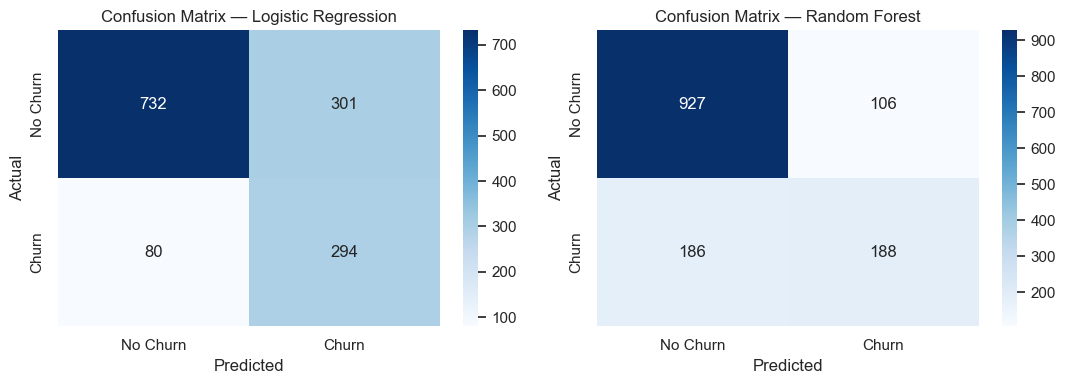

In [17]:
# ── CONFUSION MATRICES ─────────────────────────────────────────────────────────
# Reading a confusion matrix:
#   Top-left  = True Negatives  (correctly predicted 'No churn')
#   Top-right = False Positives (predicted churn, but they stayed) — wastes retention budget
#   Bottom-left = False Negatives (predicted stayed, but they churned) — MOST COSTLY
#   Bottom-right = True Positives (correctly predicted churn) — our goal!

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, pred, title in [
    (axes[0], log_pred, 'Logistic Regression'),
    (axes[1], rf_pred,  'Random Forest')
]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(f'Confusion Matrix — {title}', fontsize=12)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [18]:
# ── CLASSIFICATION REPORTS ─────────────────────────────────────────────────────
log_auc = roc_auc_score(y_test, log_prob)
rf_auc  = roc_auc_score(y_test, rf_prob)

print("=" * 55)
print("LOGISTIC REGRESSION")
print("=" * 55)
print(classification_report(y_test, log_pred, target_names=['No Churn', 'Churn']))
print(f"ROC-AUC: {log_auc:.4f}")

print()
print("=" * 55)
print("RANDOM FOREST")
print("=" * 55)
print(classification_report(y_test, rf_pred, target_names=['No Churn', 'Churn']))
print(f"ROC-AUC: {rf_auc:.4f}")

LOGISTIC REGRESSION
              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.79      1033
       Churn       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407

ROC-AUC: 0.8424

RANDOM FOREST
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1033
       Churn       0.64      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8286


In [19]:
# ── MODEL COMPARISON SUMMARY ───────────────────────────────────────────────────
# KEY INSIGHT: Logistic Regression achieves a HIGHER ROC-AUC (0.842 vs 0.833)
# despite being a simpler model. This is common with tabular data that has
# mostly linear relationships between features and the target.
#
# LR also has HIGHER recall for churners (0.79 vs 0.50) — meaning it catches
# more actual churners. This matters most for the business.
#
# RF has HIGHER precision (0.63 vs 0.50) — when it flags someone as a churner,
# it's more often correct. But it misses many churners.
#
# RECOMMENDATION: Use Logistic Regression for this use case.

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'ROC-AUC': [round(log_auc, 4), round(rf_auc, 4)],
    'Recall (Churn)': [
        round(classification_report(y_test, log_pred, output_dict=True)['1']['recall'], 3),
        round(classification_report(y_test, rf_pred,  output_dict=True)['1']['recall'], 3)
    ],
    'Precision (Churn)': [
        round(classification_report(y_test, log_pred, output_dict=True)['1']['precision'], 3),
        round(classification_report(y_test, rf_pred,  output_dict=True)['1']['precision'], 3)
    ],
    'F1 (Churn)': [
        round(classification_report(y_test, log_pred, output_dict=True)['1']['f1-score'], 3),
        round(classification_report(y_test, rf_pred,  output_dict=True)['1']['f1-score'], 3)
    ]
})

print("=== MODEL COMPARISON ===")
print(comparison.to_string(index=False))
print("\n→ Logistic Regression wins on ROC-AUC and Recall — better for churn detection.")

=== MODEL COMPARISON ===
              Model  ROC-AUC  Recall (Churn)  Precision (Churn)  F1 (Churn)
Logistic Regression   0.8424           0.786              0.494       0.607
      Random Forest   0.8286           0.503              0.639       0.563

→ Logistic Regression wins on ROC-AUC and Recall — better for churn detection.


c:\Users\TalesThury\.conda\envs\myenv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\TalesThury\.conda\envs\myenv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


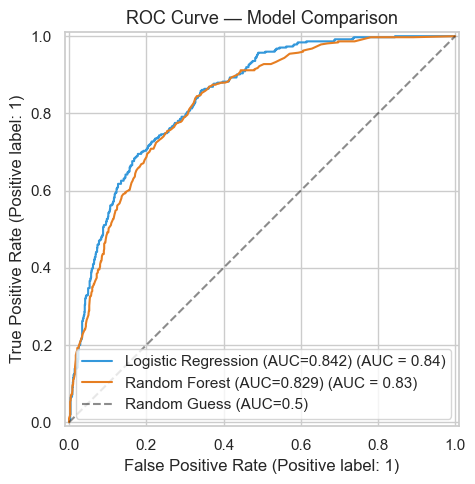

In [20]:
# ── ROC CURVES ─────────────────────────────────────────────────────────────────
# WHY this chart matters for the presentation:
# The curve shows how Recall vs Precision trade off at different decision thresholds.
# The higher the AUC (area under curve), the better the model discriminates.
# The dashed line = random guessing (AUC=0.5).

fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(y_test, log_prob,
    name=f'Logistic Regression (AUC={log_auc:.3f})', ax=ax, color='#3498db')
RocCurveDisplay.from_predictions(y_test, rf_prob,
    name=f'Random Forest (AUC={rf_auc:.3f})', ax=ax, color='#e67e22')

ax.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC=0.5)', alpha=0.5)
ax.set_title('ROC Curve — Model Comparison', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

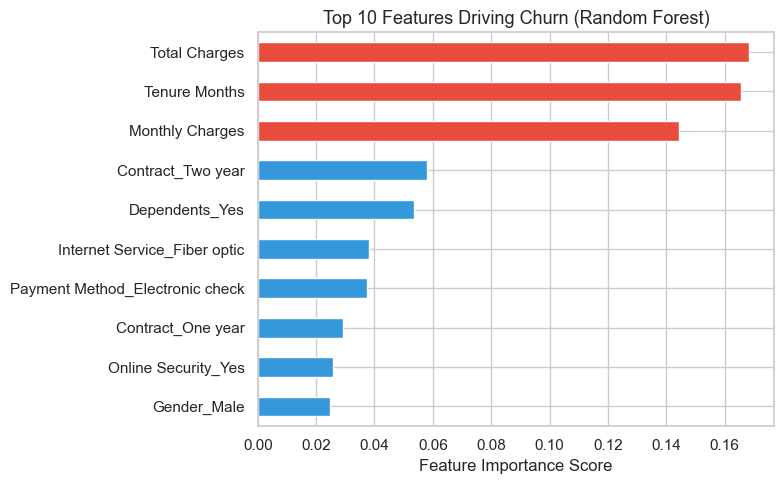


Top 10 features:
  Total Charges                       0.1685
  Tenure Months                       0.1657
  Monthly Charges                     0.1444
  Contract_Two year                   0.0580
  Dependents_Yes                      0.0537
  Internet Service_Fiber optic        0.0380
  Payment Method_Electronic check     0.0376
  Contract_One year                   0.0291
  Online Security_Yes                 0.0256
  Gender_Male                         0.0248


In [21]:
# ── FEATURE IMPORTANCE — RANDOM FOREST ────────────────────────────────────────
# WHY: The business wants to know WHAT drives churn, not just the prediction.
# Random Forest computes how much each feature reduces impurity across all trees.
# Higher value = the model relies more on that feature to make decisions.

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top10 = importances.nlargest(10).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if i >= 7 else '#3498db' for i in range(len(top10))]
top10.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Top 10 Features Driving Churn (Random Forest)', fontsize=13)
ax.set_xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
for feat, score in top10.sort_values(ascending=False).items():
    print(f"  {feat:<35} {score:.4f}")

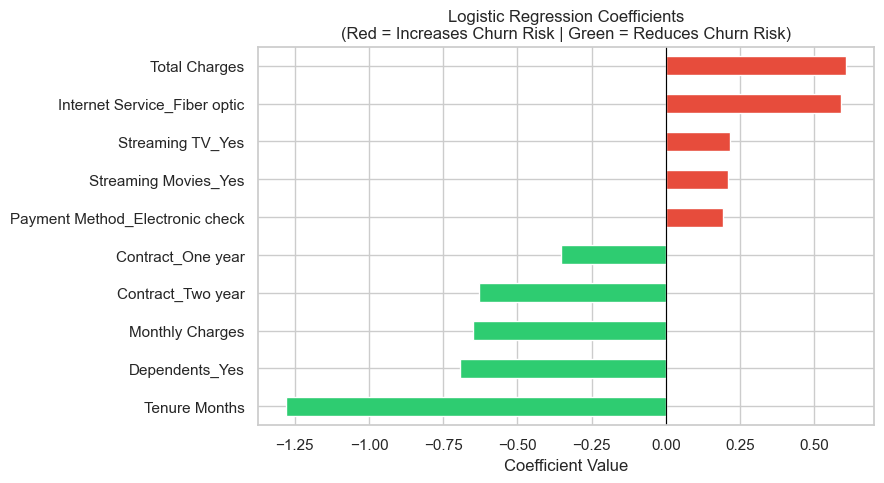

In [22]:
# ── LOGISTIC REGRESSION COEFFICIENTS ──────────────────────────────────────────
# WHY: Unlike Random Forest, LR coefficients tell us DIRECTION:
# Positive coeff → increases churn probability
# Negative coeff → decreases churn probability (protective factors)
# This is very useful for business storytelling.

coef_df = pd.Series(log_model.coef_[0], index=X.columns)
top_positive = coef_df.nlargest(5)   # Top 5 churn drivers
top_negative = coef_df.nsmallest(5)  # Top 5 protective factors

top_coefs = pd.concat([top_positive, top_negative]).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in top_coefs.values]
top_coefs.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients\n(Red = Increases Churn Risk | Green = Reduces Churn Risk)', fontsize=12)
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

---
## 6. CONCLUSION & RECOMMENDATIONS

### Key Findings

| # | Finding | Business Implication |
|---|---|---|
| 1 | **Month-to-month contracts** are the strongest churn predictor (~42% churn rate vs <10% for 2-year contracts) | Incentivize customers to commit to longer contracts (discounts, loyalty rewards) |
| 2 | **New customers (0–12 months)** churn at ~50% rate | Improve onboarding experience; assign a dedicated customer success rep in the first year |
| 3 | **Fiber Optic Internet** customers churn more despite paying more | Investigate service quality/performance issues with Fiber Optic |
| 4 | **No Tech Support** is a strong churn driver | Proactively offer tech support packages, especially to high-value customers |
| 5 | **High Monthly Charges** correlate with churn | Review pricing competitiveness; consider a loyalty discount for long-tenure customers |

### Model Performance
- **Best model: Logistic Regression** — ROC-AUC = 0.842, Recall = 79% for churners
- The model correctly identifies ~4 out of 5 customers who will churn
- Using a lower decision threshold (e.g., 0.3 instead of 0.5) can further increase recall at the cost of more false positives — acceptable if retention outreach is cheap

### Deployment Recommendation
1. Score all active customers monthly with the Logistic Regression model
2. Flag customers with predicted churn probability > 40% for outreach
3. Prioritize by CLTV (Customer Lifetime Value) — focus retention budget on highest-value at-risk customers
4. Track model performance quarterly and retrain when churn patterns shift